<a href="https://colab.research.google.com/github/Sultan-ci90/AplikasiCekCuacaSederhana/blob/main/openCvPemisahanWarna.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Menampilkan Citra RGB:


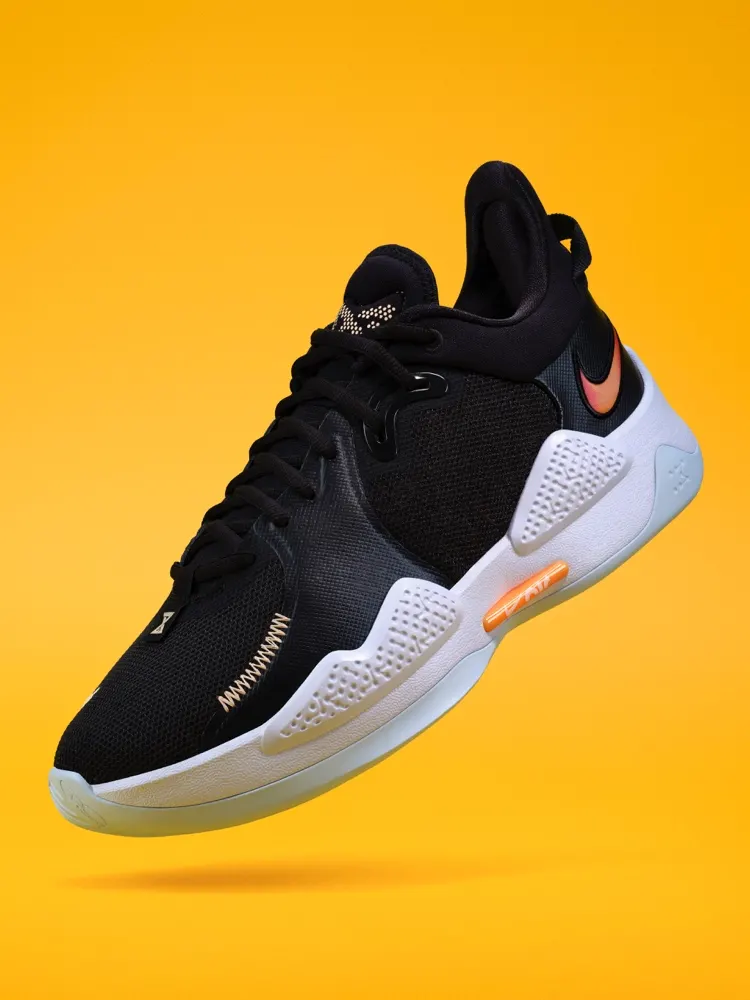

Lebar: 750px, Tinggi: 1000px, Channel: 3


In [2]:
# 1. Import library yang dibutuhkan
import cv2
from google.colab.patches import cv2_imshow # Library khusus Colab untuk menampilkan gambar

# 2. Membaca gambar (Pastikan kamu sudah upload file 'aar.jpg' ke folder di samping kiri)
img = cv2.imread('/img.jpg')

# Cek apakah gambar berhasil terbaca atau tidak
if img is None:
    print("Error: Gambar tidak ditemukan. Pastikan sudah upload file 'aar.jpg' ke panel files.")
else:
    # 3. Menampilkan gambar di dalam notebook Colab
    print("Menampilkan Citra RGB:")
    cv2_imshow(img)

    # Opsional: Menampilkan informasi ukuran gambar
    h, w, c = img.shape
    print(f"Lebar: {w}px, Tinggi: {h}px, Channel: {c}")

In [ ]:
import matplotlib.pyplot as plt


### Pemisahan Komponen Ruang Warna Gambar

Untuk memisahkan gambar ke dalam komponen ruang warna yang berbeda seperti RGB, XYZ, dan CMY (sebagai representasi CMYK), kita akan menggunakan kombinasi library `OpenCV` untuk konversi ruang warna dan `matplotlib` untuk visualisasi.

Berikut adalah penjelasan singkat tentang setiap ruang warna:

1.  **RGB (Red, Green, Blue)**:
    *   Ini adalah model warna aditif, yang berarti cahaya merah, hijau, dan biru ditambahkan bersama dalam berbagai cara untuk mereproduksi array warna yang luas.
    *   Umum digunakan di layar komputer, televisi, dan kamera digital.
    *   Setiap piksel diwakili oleh intensitas Red, Green, dan Blue.

2.  **XYZ (CIE 1931 color space)**:
    *   Ini adalah salah satu model ruang warna pertama yang didefinisikan secara matematis oleh International Commission on Illumination (CIE).
    *   Ini dirancang untuk mencakup semua warna yang terlihat oleh mata manusia dan berfungsi sebagai ruang warna referensi standar, independen dari perangkat.
    *   Komponen X, Y, Z tidak berhubungan langsung dengan warna primer fisik tetapi merupakan nilai abstrak yang mewakili luminans (Y) dan kroma (X dan Z).

3.  **CMY (Cyan, Magenta, Yellow) / CMYK (Cyan, Magenta, Yellow, Key/Black)**:
    *   Ini adalah model warna subtraktif, yang berarti warna terbentuk dengan mengurangi cahaya yang dipantulkan dari putih.
    *   Utama digunakan dalam pencetakan warna, di mana tinta diletakkan di atas substrat putih.
    *   `CMY` terdiri dari Cyan, Magenta, dan Yellow. `CMYK` menambahkan `K` (Key/Black) untuk menghasilkan warna hitam yang lebih pekat dan mengurangi penggunaan ketiga tinta warna lainnya.
    *   `OpenCV` tidak memiliki konversi langsung ke CMYK. Kami akan menghitung komponen CMY dari RGB secara manual sebagai representasi, karena K (Black) lebih kompleks dan biasanya melibatkan profil warna pencetakan.

Memproses gambar untuk pemisahan ruang warna...


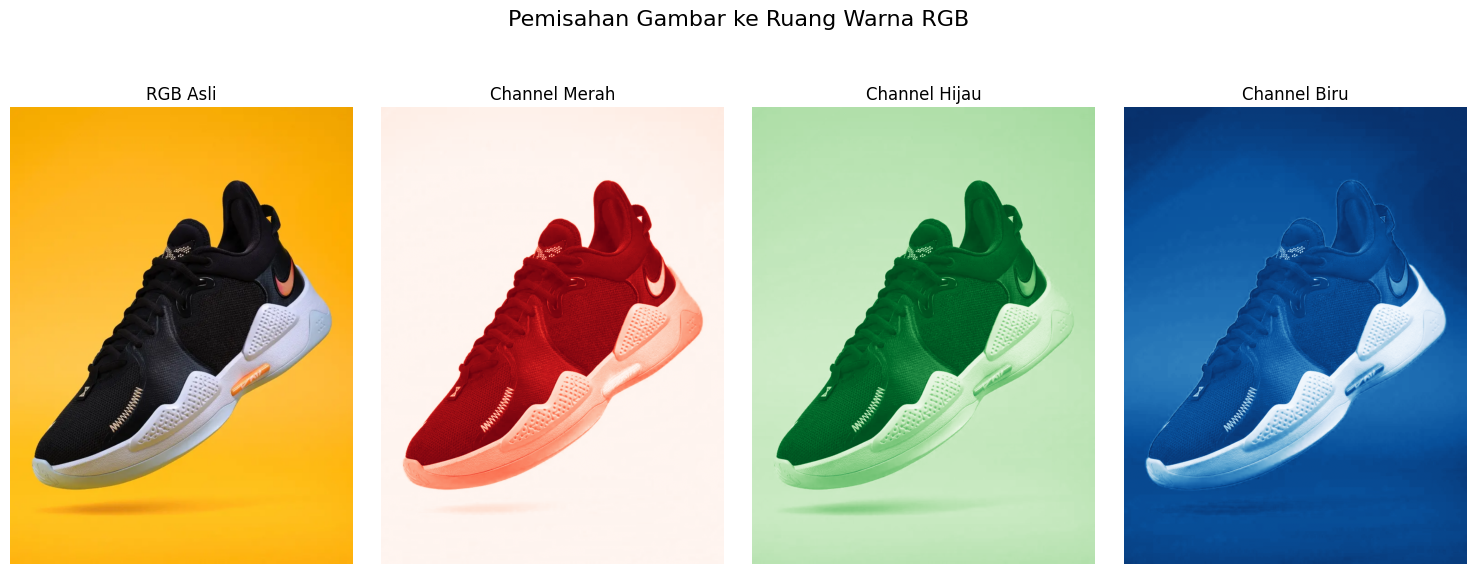

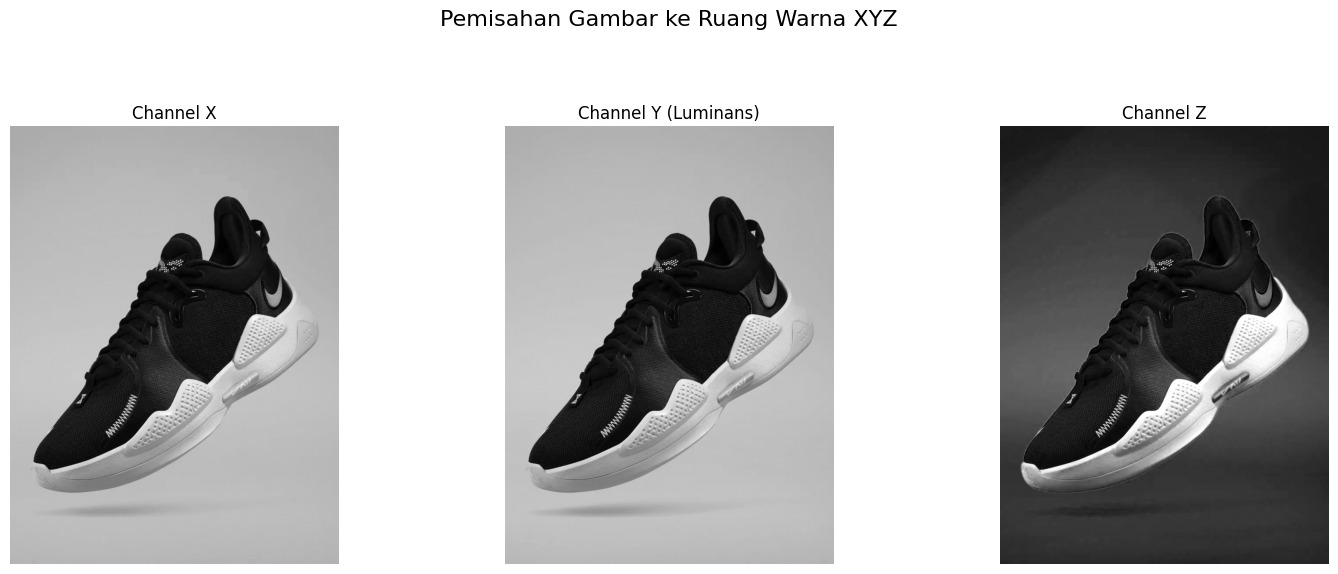

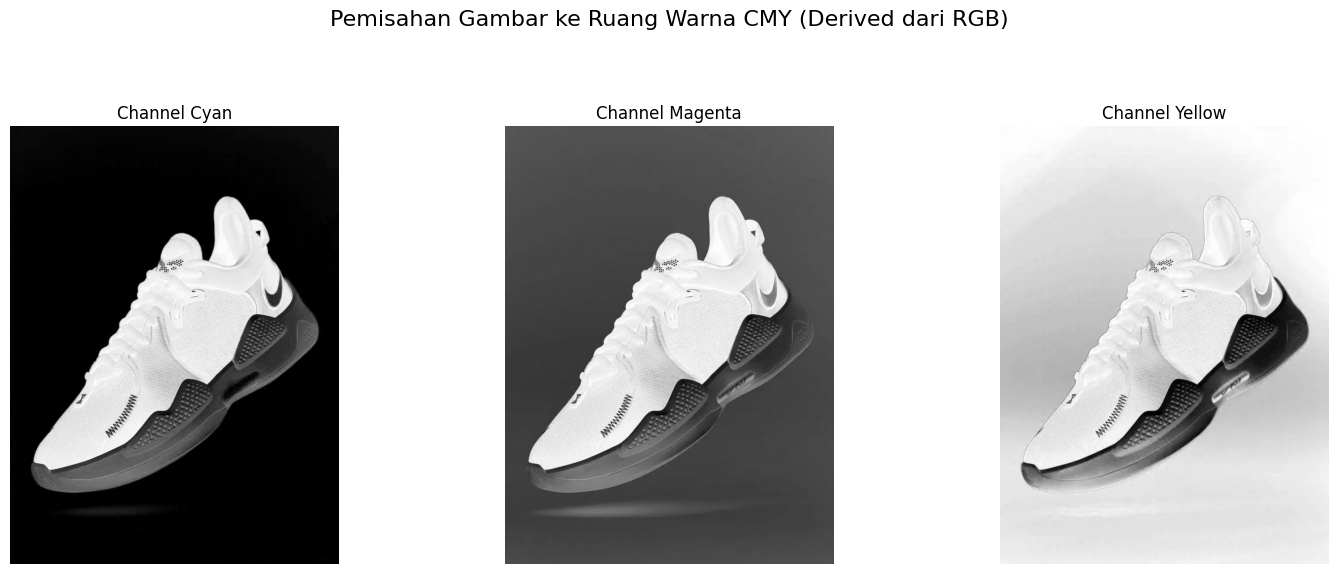


Catatan: Konversi ke CMYK secara penuh biasanya melibatkan profil warna dan algoritma yang lebih kompleks, sering digunakan dalam industri percetakan. Di sini kami menunjukkan komponen CMY yang didapat dari RGB.


In [3]:
import cv2
import matplotlib.pyplot as plt

# Memastikan variabel 'img' sudah ada dan berisi gambar
# Cell sebelumnya (7XiNfEPILSUF) harus sudah dieksekusi untuk memuat gambar.
if 'img' not in locals() or img is None:
    print("Error: Variabel 'img' tidak ditemukan atau kosong. Pastikan Anda telah menjalankan cell sebelumnya untuk memuat gambar.")
else:
    print("Memproses gambar untuk pemisahan ruang warna...")

    # --- 1. Ruang Warna RGB (Red, Green, Blue) ---
    # cv2.imread membaca gambar sebagai BGR, matplotlib mengharapkan RGB.
    rgb_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(15, 6))
    plt.suptitle('Pemisahan Gambar ke Ruang Warna RGB', fontsize=16)

    plt.subplot(1, 4, 1)
    plt.imshow(rgb_img)
    plt.title('RGB Asli')
    plt.axis('off')

    plt.subplot(1, 4, 2)
    plt.imshow(rgb_img[:, :, 0], cmap='Reds_r') # Channel Merah (semakin cerah = semakin banyak merah)
    plt.title('Channel Merah')
    plt.axis('off')

    plt.subplot(1, 4, 3)
    plt.imshow(rgb_img[:, :, 1], cmap='Greens_r') # Channel Hijau
    plt.title('Channel Hijau')
    plt.axis('off')

    plt.subplot(1, 4, 4)
    plt.imshow(rgb_img[:, :, 2], cmap='Blues_r') # Channel Biru
    plt.title('Channel Biru')
    plt.axis('off')
    plt.tight_layout(rect=[0, 0.03, 1, 0.9]) # Menyesuaikan layout agar suptitle tidak terpotong
    plt.show()

    # --- 2. Ruang Warna XYZ (CIE 1931) ---
    xyz_img = cv2.cvtColor(img, cv2.COLOR_BGR2XYZ)

    plt.figure(figsize=(15, 6))
    plt.suptitle('Pemisahan Gambar ke Ruang Warna XYZ', fontsize=16)

    plt.subplot(1, 3, 1)
    plt.imshow(xyz_img[:, :, 0], cmap='gray')
    plt.title('Channel X')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(xyz_img[:, :, 1], cmap='gray')
    plt.title('Channel Y (Luminans)')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(xyz_img[:, :, 2], cmap='gray')
    plt.title('Channel Z')
    plt.axis('off')
    plt.tight_layout(rect=[0, 0.03, 1, 0.9])
    plt.show()

    # --- 3. Ruang Warna CMY (Cyan, Magenta, Yellow) ---
    # OpenCV tidak memiliki konversi langsung ke CMYK. Kita bisa mendapatkan CMY dari RGB.
    # Konversi BGR ke RGB terlebih dahulu untuk perhitungan CMY.
    rgb_for_cmy = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Normalisasi nilai RGB ke rentang 0-1
    rgb_normalized = rgb_for_cmy.astype(float) / 255.0

    # Hitung komponen CMY
    C = 1 - rgb_normalized[:, :, 0]
    M = 1 - rgb_normalized[:, :, 1]
    Y = 1 - rgb_normalized[:, :, 2]

    plt.figure(figsize=(15, 6))
    plt.suptitle('Pemisahan Gambar ke Ruang Warna CMY (Derived dari RGB)', fontsize=16)

    plt.subplot(1, 3, 1)
    plt.imshow(C, cmap='gray')
    plt.title('Channel Cyan')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(M, cmap='gray')
    plt.title('Channel Magenta')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(Y, cmap='gray')
    plt.title('Channel Yellow')
    plt.axis('off')
    plt.tight_layout(rect=[0, 0.03, 1, 0.9])
    plt.show()

    print("\nCatatan: Konversi ke CMYK secara penuh biasanya melibatkan profil warna dan algoritma yang lebih kompleks, sering digunakan dalam industri percetakan. Di sini kami menunjukkan komponen CMY yang didapat dari RGB.")